# K Nearest Neighbours Classifier


1.  [Imports](#scrollTo=Izuws63frWoq&line=1&uniqifier=1)
2.  [Data Praparation](#scrollTo=THLfjwqqsK63&line=1&uniqifier=1)
3.  [KNN Model - Training, Evaluation](#scrollTo=iA4wh_HWwAou&line=1&uniqifier=1)
4.  [Hyperparamenter Tuning](#scrollTo=VWGhX0SJBVlv&line=1&uniqifier=1)
5.  [Advanced KNN Variantions](#scrollTo=ynnQPDnwDCTv&line=1&uniqifier=1)
6. [Model Evaluation](#scrollTo=wMY-kPXSxYLv&line=1&uniqifier=1)
7. [Conclusion](#scrollTo=AojSUwoJj0QP)
8. [Refecences](#scrollTo=m1yGl81ljon5)



# 1. Imports

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)

# 2. Dataset Preparation

## 2.1. Loading Dataset

In [ ]:
# Load the Breast Cancer dataset
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display the first five rows
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2.2 Dataset Overview

In [ ]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFeature Names:", data.feature_names)
print("\nTarget Classes:", data.target_names)

Dataset Shape: (569, 31)

Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Classes: ['malignant' 'benign']


## Check Class Distribution

In [ ]:
df['target'].value_counts(normalize=True)

,proportion
target,
1,0.627417
0,0.372583


The dataset is relatively balanced (67/37), making it suitable for binary classification without imbalance concerns.

## 2.3 Data Preprocessing

**Proper preprocessing is crucial for KNN as it relies on distance metrics.**

In [ ]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


**KNN is sensitive to the scale of the data. We'll standardize the features using StandardScaler.**

In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

# 3. KNN Model - Training, Evaluation

## 3.1 Basic KNN with Default Parameters

In [ ]:
# Initialize KNN with default parameters (n_neighbors=5)
knn = KNeighborsClassifier()

# Fit the model
knn.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = knn.predict(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.96


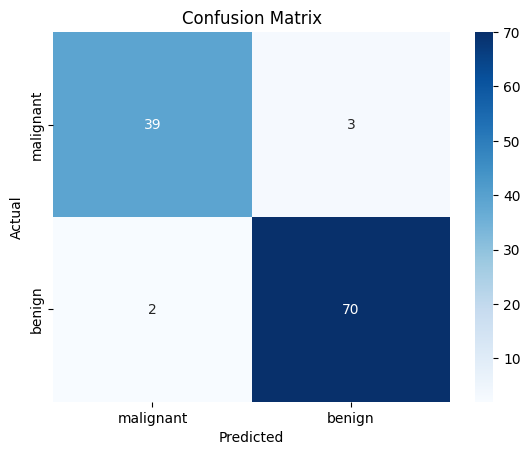

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# Hyperparameter Tuning

## GridSearch for optimal K

In [ ]:
# Define the parameter grid
param_grid = {'n_neighbors': np.arange(1, 31)}

# Initialize GridSearchCV
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')

# Fit the grid search
grid.fit(X_train_scaled, y_train)

# Best parameters
print(f"Best number of neighbors: {grid.best_params_['n_neighbors']}")

# Best cross-validation accuracy
print(f"Best cross-validation accuracy: {grid.best_score_:.2f}")


Best number of neighbors: 8
Best cross-validation accuracy: 0.97


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


## Retrain with Optimal K

In [ ]:
# Get the best K
best_k = grid.best_params_['n_neighbors']

# Initialize KNN with best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)

# Fit the model
knn_best.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_best = knn_best.predict(X_test_scaled)

# Evaluate
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Test Accuracy with K={best_k}: {accuracy_best:.2f}")


Test Accuracy with K=8: 0.97


## Cross-Validation Scores

In [ ]:
# Cross-validation scores
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_skf = cross_val_score(knn_best, X_train_scaled, y_train, cv=skf, scoring='accuracy')
#OR
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_kf = cross_val_score(knn_best, X_train_scaled, y_train, cv=kf, scoring='accuracy')
# print(f"Cross-validation scores (StratifiedKFold): {cv_scores_skf}")
print(f"Mean CV Accuracy (StratifiedKFold): {cv_scores_skf.mean():.2f}")

# print(f"Cross-validation scores: {cv_scores_kf}")
print(f"Mean CV Accuracy: {cv_scores_kf.mean():.2f}")

Mean CV Accuracy (StratifiedKFold): 0.97
Mean CV Accuracy: 0.97


# Advanced KNN Variations

## Weighted KNN

Weighted KNN assigns different weights to neighbors based on their distance. Closer neighbors have higher weights.

In [ ]:
# Initialize Weighted KNN
knn_weighted = KNeighborsClassifier(n_neighbors=best_k, weights='distance')

# Fit the model
knn_weighted.fit(X_train_scaled, y_train)

# Predict
y_pred_weighted = knn_weighted.predict(X_test_scaled)

# Evaluate
accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
print(f"Weighted KNN Accuracy: {accuracy_weighted:.2f}")


Weighted KNN Accuracy: 0.97


## Using Different Distance Metrics

KNN can use various distance metrics. Let's compare Euclidean and Manhattan distances.

In [ ]:
# Initialize KNN with Manhattan distance
knn_manhattan = KNeighborsClassifier(n_neighbors=best_k, metric='manhattan')

# Fit the model
knn_manhattan.fit(X_train_scaled, y_train)

# Predict
y_pred_manhattan = knn_manhattan.predict(X_test_scaled)

# Evaluate
accuracy_manhattan = accuracy_score(y_test, y_pred_manhattan)
print(f"Manhattan KNN Accuracy: {accuracy_manhattan:.2f}")


Manhattan KNN Accuracy: 0.96


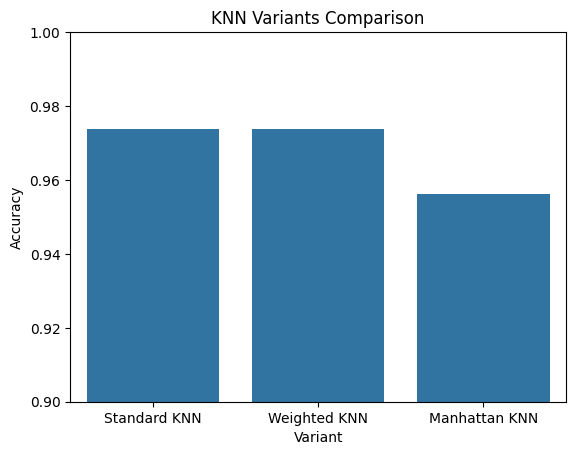

In [ ]:
# Summary of accuracies
variants = {
    'Standard KNN': accuracy_best,
    'Weighted KNN': accuracy_weighted,
    'Manhattan KNN': accuracy_manhattan
}

# Create a DataFrame for visualization
variant_df = pd.DataFrame(list(variants.items()), columns=['Variant', 'Accuracy'])

# Plot
sns.barplot(x='Variant', y='Accuracy', data=variant_df)
plt.ylim(0.90, 1.00)
plt.title('KNN Variants Comparison')
plt.show()




---



# Model Evaluation

### Accuracy score

In [18]:
accuracy = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.97


### Confusion Matrix

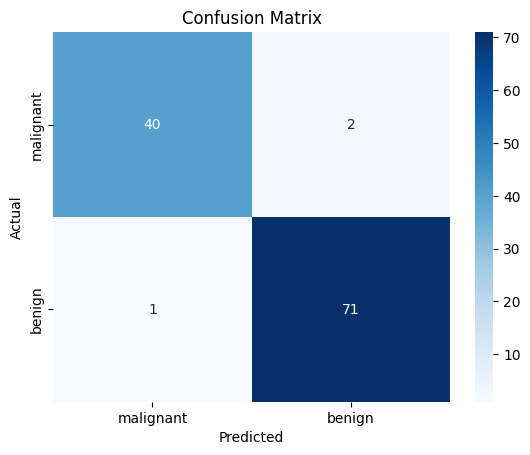

In [19]:
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

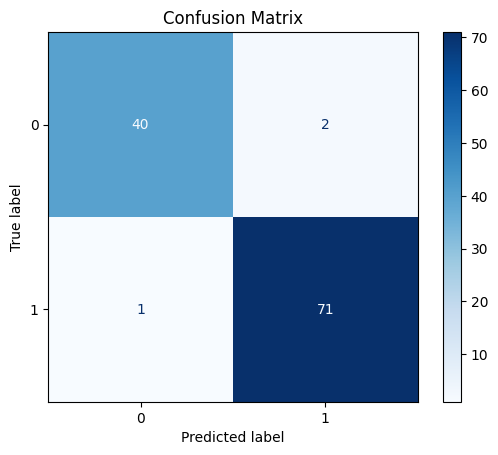

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

### Classification report

In [21]:
# Classification Report
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**Support** is the number of actual occurrences of the class in the specified dataset.

### Estimate Probabilities
Since KNN return only labels, we need to estimate the probabilities. Luckily there is such a function in sklearn inmplementation of KNN Classifier.

Once the nearest neighbors are identified, `predict_proba` calculates the probability of each class by considering the proportion of neighbors belonging to each class.

In [22]:
# Predict probabilities for ROC
y_proba = knn_best.predict_proba(X_test_scaled)[:,1]

### Receiver Operator Characteristic curve, ROC curve

In [23]:
# Compute ROC curve and AUC
def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure()
    plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], 'k--')  # Diagonal
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

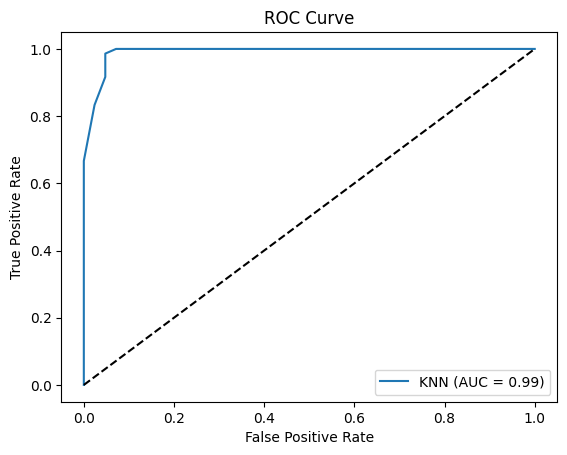

In [24]:
plot_roc_curve(y_test, y_proba)

### Interpretation of ROC Curve and AUC

Mathematically, the **ROC (Receiver Operating Characteristic) Curve** plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various threshold settings. The **Area Under the Curve (AUC)** represents the probability that the classifier will rank a randomly chosen positive instance higher than a randomly chosen negative instance.

### Key Components:
- **True Positive Rate (TPR)**, also known as **Recall**:
  
  $TPR = \frac{TP}{TP + FN}$
  
  TPR indicates the proportion of actual positives correctly identified by the classifier.

- **False Positive Rate (FPR)**:
  
  $FPR = \frac{FP}{FP + TN}$
  
  FPR represents the proportion of actual negatives incorrectly labeled as positives.

### ROC Curve Plot:
The ROC curve plots **FPR** on the x-axis and **TPR** on the y-axis, illustrating the trade-off between sensitivity and specificity across different classification thresholds. A classifier with no discriminative power would follow the diagonal line (random guess), while a good classifier will have a curve that rises steeply towards the top left corner.

### Area Under the ROC Curve (AUC):
- **AUC-ROC** is a single scalar value summarizing the ROC Curve, representing the overall performance of the classifier across all thresholds.
  
  - **AUC = 1**: Perfect classifier that completely distinguishes between positive and negative classes.
  - **AUC = 0.5**: Random classifier with no discriminative ability (the diagonal line).
  - **AUC < 0.5**: Worse than random; the classifier inversely discriminates the classes, which is generally problematic.

### Higher AUC-ROC values:
Higher AUC values indicate that the classifier can achieve a high true positive rate (recall) without a corresponding high false positive rate, meaning it can better separate the positive class from the negative class.

### Lower AUC-ROC values:
Lower AUC values suggest that the classifier struggles to distinguish between the classes, often performing only marginally better than random guessing.

### When to Use AUC-ROC:
- **Balanced Classes**: AUC-ROC is particularly informative when the positive and negative classes are roughly balanced.
- **Comparing Classifiers**: It is commonly used to compare the overall discriminatory power of different classifiers.

---

### Practical Use Cases:
1. **Medical Diagnostics**: In situations where it's crucial to correctly identify true positives (e.g., diagnosing a disease), AUC-ROC helps assess the classifier's ability to capture true cases without generating too many false alarms.
2. **Fraud Detection**: In fraud detection, AUC-ROC helps determine the model's effectiveness in identifying fraudulent transactions while minimizing the misclassification of legitimate transactions as fraud.

In summary, the ROC Curve provides insight into the balance between recall and false positive rate at different thresholds, while AUC-ROC offers a single metric that quantifies the model's overall ability to distinguish between positive and negative classes across all thresholds.


### Class score distribution

In [25]:
def plot_class_score_distribution(y_true, y_prob):
    """
    Plots the class score distribution for two classes based on two arrays.

    Parameters:
    - y_true: array-like, ground truth binary labels (0 or 1)
    - y_prob: array-like, predicted scores or probabilities for the positive class
    """
    plt.figure(figsize=(8, 6))

    # Plot KDE for each class
    for class_value, color, linestyle in zip(np.unique(y_true), ['darkorange', 'navy'], ['-', '--']):
        subset_scores = y_prob[np.array(y_true) == class_value]
        sns.kdeplot(
            subset_scores,
            color=color,
            linestyle=linestyle,
            label=f'Z={class_value}',
            fill=True,
            alpha=0.3
        )

    # Add legend, labels, and title
    plt.legend(title="Class")
    plt.xlabel('Estimated Propensity Score')
    plt.ylabel('Density')
    plt.title('Class Score Distribution')
    plt.show()

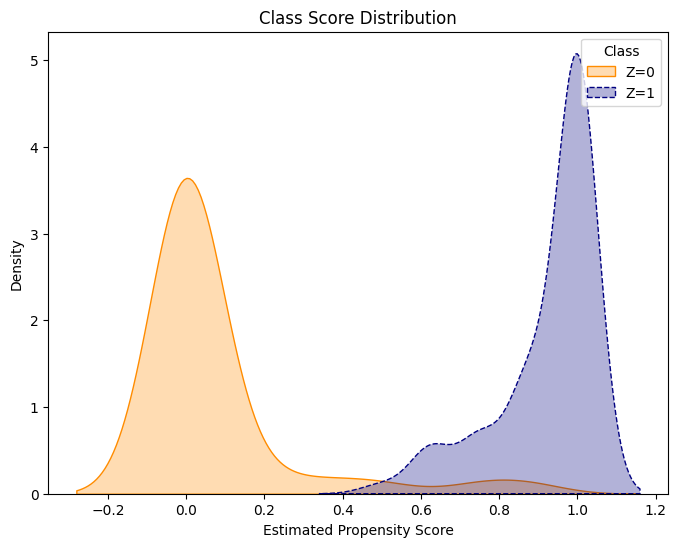

In [26]:
plot_class_score_distribution(y_test, y_proba)

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall_curve(y_true, y_prob, pos_label=1):
    """
    Plots the Precision-Recall curve for a binary classifier.

    Parameters:
    - y_true: array-like of shape (n_samples,), ground truth binary labels (0 or 1)
    - y_scores: array-like of shape (n_samples,), predicted scores or probabilities for the positive class
    - pos_label: int, the label of the positive class (default is 1)
    """
    # Calculate precision-recall pairs for different probability thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob, pos_label=pos_label)
    avg_precision = average_precision_score(y_true, y_prob)

    # Plot Precision-Recall curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='b', linewidth=2, label=f'AP = {avg_precision:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()


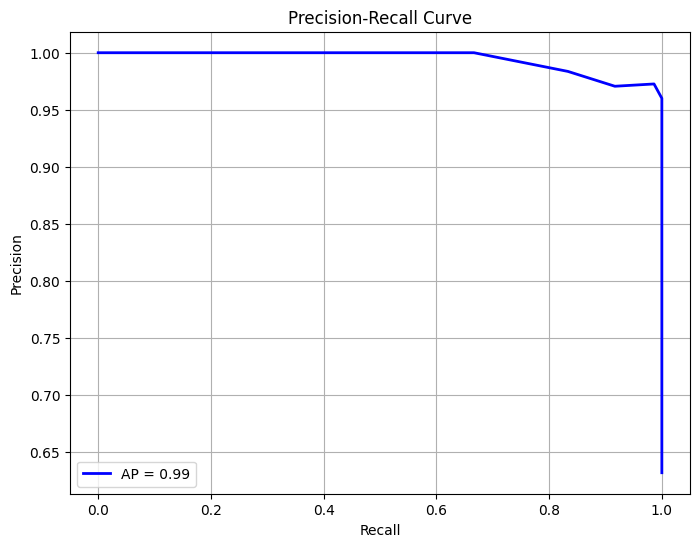

In [28]:
plot_precision_recall_curve(y_test, y_proba)

**TL;DR:** Average Precision (AP) is a single-number summary of the Precision-Recall (PR) curve, representing the area under the PR curve. It captures how well a binary classifier distinguishes positive from negative examples, especially in imbalanced datasets.

### **Interpretation of Average Precision (AP)**


Mathematically, AP is calculated by summing up the precision values at different recall thresholds, weighted by the change in recall:
$AP = \sum_{i}(R_{i} - R_{i-1})\cdot P_{i}, $

where $R_{i}$ and $P_{i}$ are the recall and precision values at threshold $i$.


**Higher AP values** (closer to 1) indicate that the classifier maintains a high level of precision even as recall increases, meaning it can capture positive instances without introducing too many false positives.


**Lower AP values** suggest that as recall increases, precision drops, indicating that the model struggles to balance capturing positives without mistakenly labeling negatives as positives.
Relationship with AUC-PR:

AP is closely related to the Area Under the Precision-Recall Curve (AUC-PR). In fact, AP is often considered a version of AUC-PR where precision is averaged over all recall levels.
Unlike traditional ROC-AUC (which considers both classes equally), **AP and AUC-PR emphasize the model’s performance on the positive class,** which is crucial in imbalanced datasets.

**When to Use AP:**

**For Imbalanced Classes:** AP is particularly useful in domains like medical diagnostics, fraud detection, and anomaly detection, where the positive class (e.g., disease, fraud) is rare but important to identify.


**Evaluating High Recall Systems:** If capturing all positives is critical, AP can help balance the need for high recall without drastically sacrificing precision.

### Estimating Threshold

#### Optimal threshold based on F1 score

In [29]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

def find_optimal_threshold(y_true, y_prob):
    """
    Finds the optimal threshold based on F1 score, and provides insights using PR curve.

    Parameters:
    - y_true: array-like, ground truth binary labels (0 or 1)
    - y_prob: array-like, predicted scores or probabilities for the positive class

    Returns:
    - optimal_thresholds: dict with optimal thresholds for F1 score and PR curve insights
    """
    # Calculate precision, recall, thresholds for PR Curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    # Method 1: Using F1 score
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)  # Avoid division by zero
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold_f1 = thresholds[optimal_idx]

    # Method 2: Midpoint of precision and recall (if you want balanced precision and recall)
    pr_diff = np.abs(precision - recall)
    optimal_idx_pr = np.argmin(pr_diff)
    optimal_threshold_pr_balance = thresholds[optimal_idx_pr]

    # Collect results
    optimal_thresholds = {
        "F1_score": optimal_threshold_f1,
        "Precision-Recall_Balance": optimal_threshold_pr_balance
    }

    # Plot Precision-Recall curve with marked optimal thresholds
    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, label='PR Curve', color='blue')
    plt.scatter(recall[optimal_idx], precision[optimal_idx], color='red', label=f'Optimal F1 Threshold = {optimal_threshold_f1:.2f}')
    plt.scatter(recall[optimal_idx_pr], precision[optimal_idx_pr], color='green', label=f'Balanced PR Threshold = {optimal_threshold_pr_balance:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve with Optimal Thresholds')
    plt.legend(loc='lower left')
    plt.grid()
    plt.show()

    return optimal_thresholds


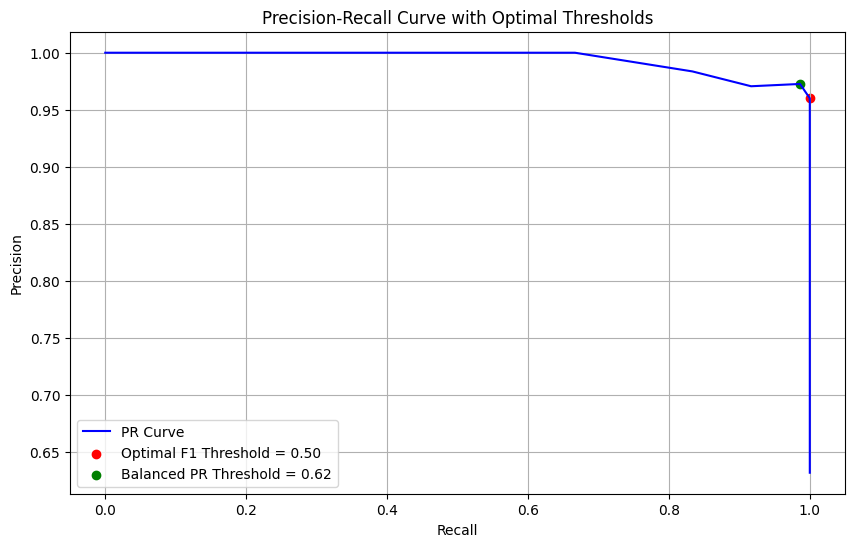

{'F1_score': 0.5, 'Precision-Recall_Balance': 0.625}

In [30]:
find_optimal_threshold(y_test, y_proba)

Youden's J Statistic (Optimal ROC Threshold)

In [31]:
from sklearn.metrics import roc_curve

def optimal_threshold_youden(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]
    return optimal_threshold

In [32]:
optimal_threshold_youden(y_test, y_proba)

0.625

In [33]:
y_hat_adj = np.where(y_proba > 0.4, 1, 0)
# classification report
print(classification_report(y_test, y_hat_adj))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        42
           1       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [34]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



#### Maximizing Specificity and Sensitivity Balance

In [35]:
def optimal_threshold_sensitivity_specificity(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    specificity = 1 - fpr
    balance = np.abs(specificity - tpr)
    optimal_idx = np.argmin(balance)
    optimal_threshold = thresholds[optimal_idx]
    return optimal_threshold

In [36]:
optimal_threshold_sensitivity_specificity(y_test, y_proba)

0.625

# Conclusion



In this guide, we explored the **K-Nearest Neighbors (KNN) classifier** using the Breast Cancer Wisconsin dataset. The key steps we covered include:

- **Data Loading and Exploration**: Understanding the dataset and its class distribution.
- **Data Preprocessing**: Scaling the features, which is crucial for KNN due to its reliance on distance metrics.
- **Model Implementation**: Building and evaluating a basic KNN model with default parameters.
- **Hyperparameter Tuning**: Using Grid Search to find the optimal number of neighbors (K).
- **Advanced Variations**: Implementing **Weighted KNN** and experimenting with different distance metrics (Euclidean vs. Manhattan) to observe their impact on performance.


### Key Takeaways:



- **Feature Scaling**: Always scale your features when using KNN, as the algorithm relies on distance calculations which are affected by feature magnitude.
- **Choosing K**: A smaller value for K can lead to overfitting, while a larger K may cause underfitting. **Cross-validation** is an effective way to find the optimal value of K that balances bias and variance.
- **Weighted KNN and Distance Metrics**: Assigning weights based on distance can improve the model, especially if some neighbors are closer and therefore more relevant. Trying different distance metrics, such as Manhattan distance, can also provide better results depending on the data characteristics.

KNN is a straightforward yet powerful algorithm, making it an excellent choice for introducing machine learning concepts. It also provides a good foundation for understanding more complex algorithms and concepts in machine learning.

# References



- [Scikit-learn K-Nearest Neighbors Documentation](https://scikit-learn.org/stable/modules/neighbors.html)
- [Grid Search and Cross-Validation in Scikit-Learn](https://scikit-learn.org/stable/modules/grid_search.html)